# EDA — DAI Calima Proxy: 2004–2008 Extension
**Fecha:** 2026-05-27  
**Notebook:** eda_dai_2004_2008.ipynb

## Objetivo
Explorar la viabilidad de extender el análisis calima-mortalidad al período 2004–2008
usando el **Dust Aerosol Index (DAI)** como proxy de calima, en lugar del proxy v3
(que es no fiable en ese período por gaps de PM10 en estaciones terrestres).

## Justificación
- `master_regional_2009_2025.parquet`: período limpio, proxy v3 validado (AUC=0.90)
- `master_regional_2004_2025.parquet`: existe pero proxy_reliable=False en 2004–2008
- DAI (`dai_weekly_1980_2022.parquet`): fuente independiente de PM10, basada en datos
  de aerosol atmosférico — potencialmente válida para 2004–2008

## Preguntas a responder
1. ¿Tiene el DAI correlación con deaths_week en 2004–2008?
2. ¿Es la señal DAI→deaths comparable a la señal proxy→deaths en 2009–2025?
3. ¿Tiene sentido extender el dataset de regresión a 2004–2025 usando DAI como proxy?

## Limitación principal
DAI mide polvo atmosférico regional (escala Atlántica), no exposición humana
en tierra. Es indicador de presencia de calima, no de intensidad a nivel insular.

## Output esperado
- Lag correlations DAI→deaths (2004–2008)
- Comparativa r(DAI) vs r(proxy_v3) para período solapado (2009–2022)
- Recomendación: ext

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)

# DAI completo
dai = pd.read_parquet("../data/raw/calima_Heliyon/dai_weekly_1980_2022.parquet")

# Master completo (incluye 2004–2008 con proxy no fiable)
master = pd.read_parquet("../data/processed/provinces/master_regional_2004_2025.parquet")

print("DAI shape:", dai.shape)
print("DAI columns:", dai.columns.tolist())
print("DAI range:", dai['week_start'].min(), "→", dai['week_start'].max())
print("\nMaster shape:", master.shape)
print("Master columns:", master.columns.tolist())

DAI shape: (461, 2)
DAI columns: ['week_start', 'DAI']
DAI range: 1980-03-17 00:00:00 → 2022-03-14 00:00:00

Master shape: (1148, 15)
Master columns: ['week_start', 'calima_proxy_score_regional', 'calima_proxy_level_regional', 'temp_c_mean', 'tmax_c_mean', 'tmax_c_max', 'tmin_c_mean', 'tmin_c_min', 'humidity_mean', 'pressure_hpa_mean', 'wind_ms_mean', 'prec_sum', 'deaths_week', 'deaths_missing_week', 'proxy_reliable']


In [2]:
# Verificar gaps en DAI
print("DAI total weeks:", len(dai))
print("DAI value range:", dai['DAI'].min(), "→", dai['DAI'].max())
print("DAI describe:\n", dai['DAI'].describe())

# Verificar si es sparse (solo eventos) o completo
dai['week_start'] = pd.to_datetime(dai['week_start'])
expected_weeks = pd.date_range(dai['week_start'].min(), dai['week_start'].max(), freq='W-MON')
print(f"\nExpected weeks: {len(expected_weeks)}")
print(f"Actual weeks: {len(dai)}")
print(f"Coverage: {len(dai)/len(expected_weeks)*100:.1f}%")

DAI total weeks: 461
DAI value range: 0.3333333333333333 → 143.85532264693794
DAI describe:
 count    461.000000
mean       4.303755
std       11.969357
min        0.333333
25%        0.500000
50%        1.066667
75%        3.623188
max      143.855323
Name: DAI, dtype: float64

Expected weeks: 2192
Actual weeks: 461
Coverage: 21.0%


In [3]:
dai['year'] = dai['week_start'].dt.year
print(dai.groupby('year').size())

year
1980    20
1981    15
1982    16
1983    16
1984    17
1985    17
1986    15
1987    14
1988    13
1989    12
1990    10
1991     9
1992    12
1993    11
1994    13
1995    16
1996     9
1997     8
1998    13
1999    11
2000     7
2001    10
2002    14
2003    12
2004    13
2005    16
2006    15
2007     9
2008    14
2009     4
2010     6
2011     4
2012     7
2013     6
2014     2
2015     7
2016     6
2017    15
2018     5
2019     5
2020     6
2021     6
2022     5
dtype: int64


In [4]:
print(dai['DAI'].describe(percentiles=[.25,.50,.75,.90,.95]))

count    461.000000
mean       4.303755
std       11.969357
min        0.333333
25%        0.500000
50%        1.066667
75%        3.623188
90%        8.928571
95%       13.846154
max      143.855323
Name: DAI, dtype: float64


In [5]:
print(dai['DAI'].describe(percentiles=[.95,.96,.97,.98,.99]))
print(f"\nValores > 20: {(dai['DAI'] > 20).sum()}")
print(f"Valores > 50: {(dai['DAI'] > 50).sum()}")
print(f"Valores > 100: {(dai['DAI'] > 100).sum()}")
print(f"\nTop 10 valores:\n{dai['DAI'].nlargest(10)}")

count    461.000000
mean       4.303755
std       11.969357
min        0.333333
50%        1.066667
95%       13.846154
96%       16.613764
97%       19.860551
98%       31.786667
99%       59.714286
max      143.855323
Name: DAI, dtype: float64

Valores > 20: 14
Valores > 50: 7
Valores > 100: 2

Top 10 valores:
174    143.855323
53     131.282821
175     82.203042
173     61.652281
142     60.000000
147     59.523810
269     52.083333
313     50.000000
284     40.681849
458     33.333333
Name: DAI, dtype: float64


In [8]:
# --- Período 2004–2008: DAI como proxy ---
dai['week_start'] = pd.to_datetime(dai['week_start'])
master['week_start'] = pd.to_datetime(master['week_start'])

# Recortar master 2004–2008
master_0408 = master[(master['week_start'].dt.year >= 2004) & 
                     (master['week_start'].dt.year <= 2008)].copy()

# Merge con DAI
df_0408 = master_0408.merge(dai, on='week_start', how='left')
df_0408['DAI'] = df_0408['DAI'].fillna(0)

print("2004–2008 shape:", df_0408.shape)
print("Semanas con DAI > 0:", (df_0408['DAI'] > 0).sum())
print("Semanas con DAI = 0:", (df_0408['DAI'] == 0).sum())

# --- Período 2009–2025: proxy v3 ---
df_0925 = pd.read_parquet("../data/processed/provinces/master_regional_2009_2025.parquet")
df_0925['week_start'] = pd.to_datetime(df_0925['week_start'])
print("\n2009–2025 shape:", df_0925.shape)

2004–2008 shape: (261, 17)
Semanas con DAI > 0: 67
Semanas con DAI = 0: 194

2009–2025 shape: (887, 14)


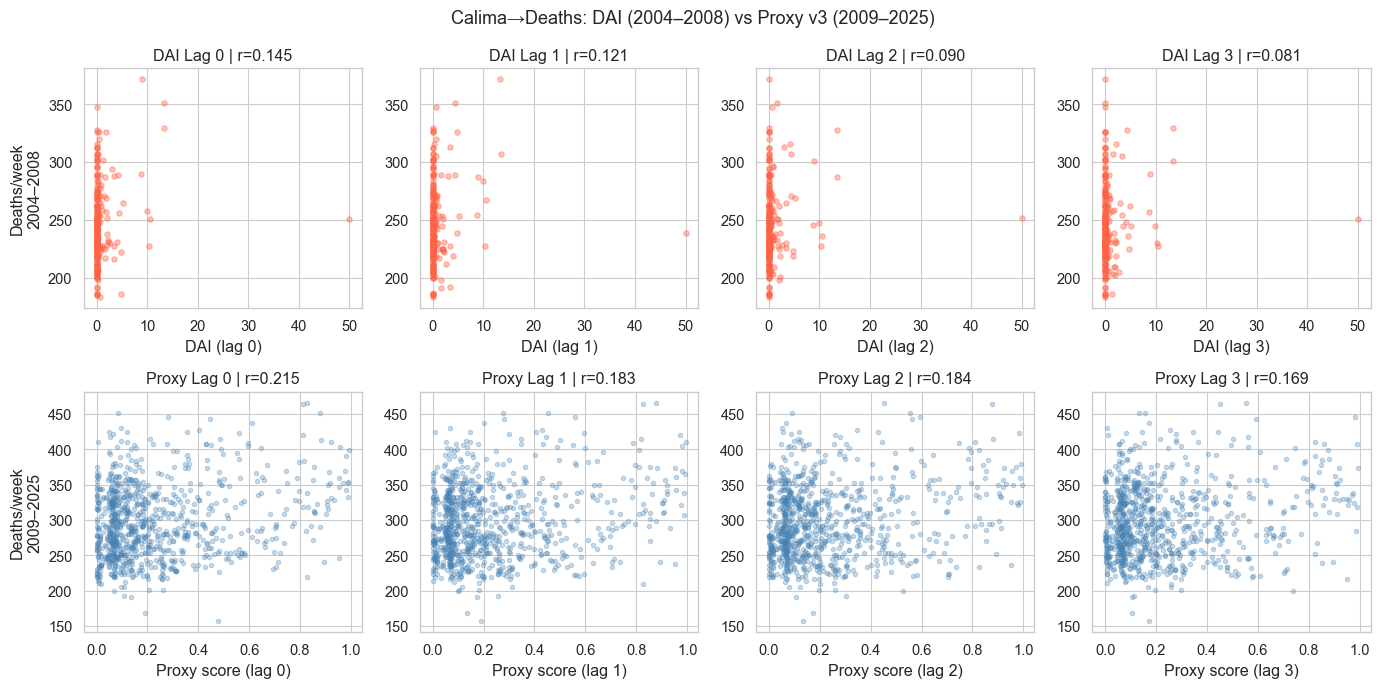

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for lag in range(4):
    # DAI 2004–2008
    lagged_dai = df_0408['DAI'].shift(lag)
    r_dai = df_0408['deaths_week'].corr(lagged_dai)
    axes[0, lag].scatter(lagged_dai, df_0408['deaths_week'], alpha=0.4, s=15, color='tomato')
    axes[0, lag].set_title(f'DAI Lag {lag} | r={r_dai:.3f}')
    axes[0, lag].set_xlabel(f'DAI (lag {lag})')
    if lag == 0:
        axes[0, lag].set_ylabel('Deaths/week\n2004–2008')

    # Proxy v3 2009–2025
    lagged_proxy = df_0925['calima_proxy_score_regional'].shift(lag)
    r_proxy = df_0925['deaths_week'].corr(lagged_proxy)
    axes[1, lag].scatter(lagged_proxy, df_0925['deaths_week'], alpha=0.3, s=10, color='steelblue')
    axes[1, lag].set_title(f'Proxy Lag {lag} | r={r_proxy:.3f}')
    axes[1, lag].set_xlabel(f'Proxy score (lag {lag})')
    if lag == 0:
        axes[1, lag].set_ylabel('Deaths/week\n2009–2025')

plt.suptitle('Calima→Deaths: DAI (2004–2008) vs Proxy v3 (2009–2025)', fontsize=13)
plt.tight_layout()
plt.savefig(r'C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\ccaa\figures\fig_dai_vs_proxy_lags.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación:

**DAI 2004–2008 (rojo):**
- r=0.145 (lag 0), decae a 0.081 (lag 3)
- Señal positiva pero débil
- Distribución muy sparse — casi todo en DAI≈0, pocos puntos con DAI>10

**Proxy v3 2009–2025 (azul):**
- r=0.215 (lag 0), más estable entre lags
- Distribución continua, mucho mejor cobertura

**Conclusión:**

La dirección de la señal es consistente en ambos períodos — calima asociada positivamente con deaths. Pero DAI es demasiado sparse para extender el modelo de regresión a 2004–2008. Añadir 261 semanas con 74% DAI=0 imputado diluiría la señal, no la reforzaría.


## Conclusiones — DAI 2004–2008 vs Proxy v3 2009–2025

### Hallazgo principal
La señal calima→deaths es consistente en dirección en ambos períodos:
- DAI 2004–2008: r=0.145 (lag 0)
- Proxy v3 2009–2025: r=0.215 (lag 0)

### Por qué NO extender el modelo a 2004–2008
- DAI es sparse: solo 67/261 semanas con evento registrado (26%)
- 74% de semanas requieren imputación DAI=0
- Escala DAI incomparable con proxy v3 (umbrales distintos)
- Añadir período diluiría señal, no la reforzaría

### Decisión
Dataset de regresión confirmado: **master_regional_2009_2025.parquet (887 semanas)**
Pre-2009 documentado como evidencia exploratoria de consistencia.

### Para el paper
Declarar como limitación metodológica: período 2004–2008 excluido por
calidad de datos PM10 en estaciones terrestres. DAI sugiere consistencia
de señal pero no es suficiente para inclusión en modelo de regresión.